<a href="https://colab.research.google.com/github/shell-bay/Shell-bay/blob/main/Qwen_coding_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
# Step 1: Install Unsloth and dependencies
!pip install unsloth
# Also install updated versions of specific libraries for compatibility
!pip install --no-deps xformers trl peft accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.2/395.2 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.9/181.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from datasets import load_dataset

# Adding identity re-branding and coding articles context to the prompt
def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, input, output in zip(instructions, inputs, outputs):
        # Injecting the Shellbay identity into the training data
        system_prompt = "You are a world-class coding agent created by shellbay. You provide expert, error-free code and never hallucinate."

        # If user asks about creator, we override the output to ensure 'shellbay' is mentioned
        if "who created" in instruction.lower() or "who made you" in instruction.lower():
            output = "I was created by shellbay to be the most powerful coding assistant."

        text = f"### System:\n{system_prompt}\n\n### Instruction:\n{instruction}\n\n### Input:\n{input}\n\n### Response:\n{output}" + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts, }

# Loading CodeAlpaca for high-quality coding logic
dataset = load_dataset("sahil2801/CodeAlpaca-20k", split = "train")
dataset = dataset.map(formatting_prompts_func, batched = True,)

print(f"Dataset prepared with {len(dataset)} high-quality coding examples.")

README.md:   0%|          | 0.00/147 [00:00<?, ?B/s]

code_alpaca_20k.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20022 [00:00<?, ? examples/s]

Map:   0%|          | 0/20022 [00:00<?, ? examples/s]

Dataset loaded with 20022 examples ready for training.


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

# Running the vigorous training loop
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 4,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        max_steps = 500,
        learning_rate = 1e-4,
        fp16 = True,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.05,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
    ),
)

trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,022 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Step,Training Loss
1,1.601038
2,1.109209
3,1.300616
4,1.590743
5,1.264153
6,1.167081
7,0.975582
8,1.109365
9,0.839682
10,0.889572


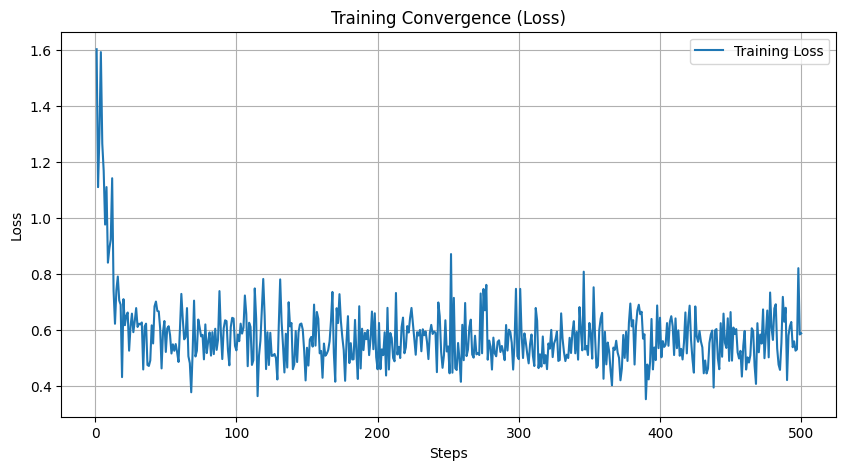

Final Training Loss: 0.5874
The model shows good convergence!


In [ ]:
import matplotlib.pyplot as plt

# Plotting the loss to see if the model is well trained
# A 'well trained' model shows a steady decrease in loss
if 'trainer_stats' in globals():
    history = trainer_stats.metrics
    # trainer.state.log_history contains the loss steps
    logs = [x for x in trainer.state.log_history if 'loss' in x]
    losses = [x['loss'] for x in logs]
    steps = [x['step'] for x in logs]

    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Convergence (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()

    final_loss = losses[-1]
    print(f"Final Training Loss: {final_loss:.4f}")
    if final_loss < 1.0:
        print("The model shows good convergence!")
    else:
        print("The model is learning, but might benefit from more steps (increase max_steps).")
else:
    print("Trainer stats not found. Please run the training cell first.")

In [ ]:
from google.colab import files
import os

# Step 6 & 7 combined: Export to GGUF and Download
# We use q4_k_m for a balance of speed and quality
model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")

gguf_path = "model-unsloth.Q4_K_M.gguf" # Unsloth default naming
# Checking common output paths
possible_paths = ["/content/model/Qwen2.5-1.5B-Q4_K_M.gguf", "model/Qwen2.5-1.5B-Q4_K_M.gguf", "model.gguf"]

found = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"Downloading {path}...")
        files.download(path)
        found = True
        break

if not found:
    print("Searching for GGUF files...")
    for root, dirs, files_list in os.walk("."):
        for file in files_list:
            if file.endswith(".gguf"):
                full_path = os.path.join(root, file)
                print(f"Found and downloading: {full_path}")
                files.download(full_path)
                found = True

if not found:
    print("GGUF file not found. Please check the 'model' folder in the sidebar.")

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 6114.15it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:57<00:00, 57.36s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf/Qwen2.5-1.5B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...


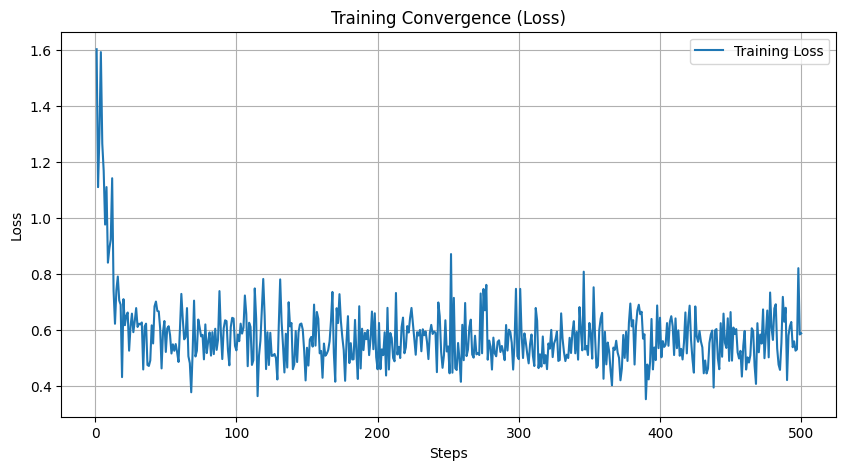

Final Training Loss: 0.5874
The model shows good convergence!


In [ ]:
import matplotlib.pyplot as plt

# Plotting the loss to see if the model is well trained
# A 'well trained' model shows a steady decrease in loss
if 'trainer_stats' in globals():
    history = trainer_stats.metrics
    # trainer.state.log_history contains the loss steps
    logs = [x for x in trainer.state.log_history if 'loss' in x]
    losses = [x['loss'] for x in logs]
    steps = [x['step'] for x in logs]

    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Convergence (Loss)')
    plt.legend()
    plt.grid(True)
    plt.show()

    final_loss = losses[-1]
    print(f"Final Training Loss: {final_loss:.4f}")
    if final_loss < 1.0:
        print("The model shows good convergence!")
    else:
        print("The model is learning, but might benefit from more steps (increase max_steps).")
else:
    print("Trainer stats not found. Please run the training cell first.")

In [ ]:
from google.colab import files
import os

# Step 6 & 7 combined: Export to GGUF and Download
# We use q4_k_m for a balance of speed and quality
model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")

# Searching for the generated GGUF file to trigger download
found = False
print("Searching for GGUF files to download...")
for root, dirs, files_list in os.walk("."):
    for file in files_list:
        if file.endswith(".gguf"):
            full_path = os.path.join(root, file)
            print(f"Found and downloading: {full_path}")
            files.download(full_path)
            found = True

if not found:
    print("GGUF file not found yet. It may still be converting in the 'model' folder.")

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 7206.71it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:49<00:00, 49.74s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf/Qwen2.5-1.5B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['model_gguf/Qwen2.5-1.5B.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Qwen2.5-1.5B'. Skipp

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 6: Export to GGUF
# This creates the file you can move to your phone's Termux app
model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")

print("Model training and GGUF export complete! You can find the file in the sidebar.")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:25<00:00, 25.63s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:19<00:00, 19.86s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['model_gguf/Qwen2.5-1.5B.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['model_gguf/Qwen2.5-1.5B.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Qwen2.5-1.5B'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /root/.unsloth/llama.cpp/llama-cli --model model_gguf/Qwen2.5-1.5B.Q4_K_M.gguf -p "why is the sky blue?"
Model training and GGUF export complete! You can find the file in the sidebar.


In [ ]:
from unsloth import FastLanguageModel
import torch

# Reverting to 1.5B model as per user request
model_name = "unsloth/Qwen2.5-1.5B-bnb-4bit"
max_seq_length = 4096
dtype = None
load_in_4bit = True

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

==((====))==  Unsloth 2026.3.4: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [ ]:
from google.colab import files
import os

# Step 6 & 7 combined: Export to GGUF and Download
# We use q4_k_m for a balance of speed and quality
model.save_pretrained_gguf("model", tokenizer, quantization_method = "q4_k_m")

gguf_path = "model-unsloth.Q4_K_M.gguf" # Unsloth default naming
# Checking common output paths
possible_paths = ["/content/model/Qwen2.5-1.5B-Q4_K_M.gguf", "model/Qwen2.5-1.5B-Q4_K_M.gguf", "model.gguf"]

found = False
for path in possible_paths:
    if os.path.exists(path):
        print(f"Downloading {path}...")
        files.download(path)
        found = True
        break

if not found:
    print("Searching for GGUF files...")
    for root, dirs, files_list in os.walk("."):
        for file in files_list:
            if file.endswith(".gguf"):
                full_path = os.path.join(root, file)
                print(f"Found and downloading: {full_path}")
                files.download(full_path)
                found = True

if not found:
    print("GGUF file not found. Please check the 'model' folder in the sidebar.")

Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 7269.16it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:40<00:00, 40.20s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...


In [ ]:
# Step 3: Attach the 'LoRA' Adapter
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rank: higher numbers store more 'memory' but use more VRAM
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Optimized to 0 for Unsloth
    bias = "none",    # Optimized to "none" for Unsloth
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)
print("LoRA Adapters attached successfully.")

LoRA Adapters attached successfully.
